# K-Means Clustering Algo 

In [1]:
import seaborn as sns
from sklearn.datasets import make_blobs

In [5]:
X, y = make_blobs(
    n_samples=1000,
    n_features=2,
    centers=4,
    random_state=42
)

<Axes: >

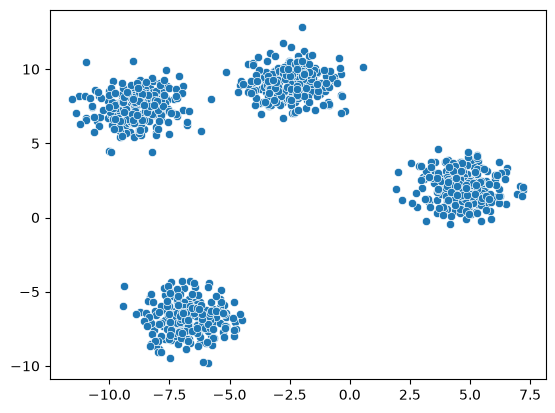

In [6]:
# Visualize the data
sns.scatterplot(x=X[:,0], y=X[:, 1])

In [7]:
# K-Means Clustring
from sklearn.cluster import KMeans

In [8]:
K = 4

kmeans = KMeans(
    n_clusters=K,
    random_state=42
)

In [9]:
labels = kmeans.fit_predict(X) 
# here labels are cluster number

<Axes: >

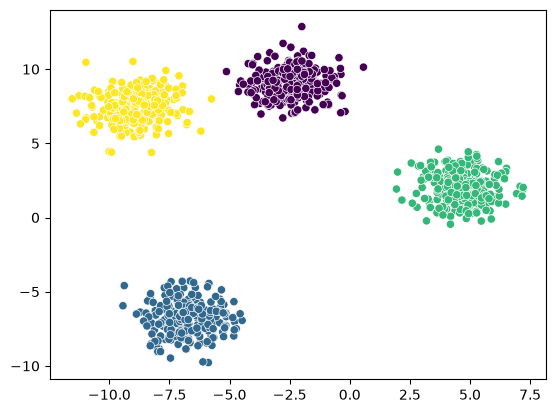

In [10]:
sns.scatterplot(x=X[:,0], y=X[:,1], c=labels)

### How To Choose our K value - elbow, & silhoute score

In [14]:
# Elbow Method

# 1. Manual way to implement Elbow method
wcss = []

for k in range(1, 21):
    kmeans= KMeans(n_clusters=k)
    kmeans.fit_predict(X)
    wcss.append(kmeans.inertia_)
    

<Axes: >

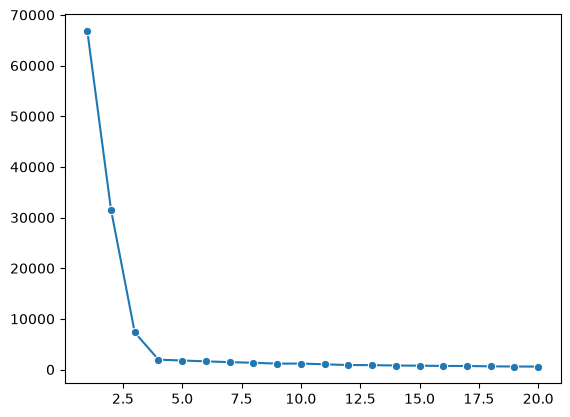

In [13]:
sns.lineplot(x=range(1, 21), y=wcss, marker='o')

In [17]:
# 2. Automatic Method: Where we use Need Module 

from kneed import KneeLocator

In [18]:
knee = KneeLocator(range(1, 21), wcss, curve="convex", direction="decreasing")

In [19]:
print("Optimal K: ", knee.knee) # knee.elbow

4


 ### Silhoutte Score

In [21]:
from sklearn.metrics import silhouette_score

In [22]:
ss = []

for k in range(2, 21): # always start from 2 not one as not making any sense like entir data into one cluster
    kmeans = KMeans(n_clusters=k)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)

    ss.append(score)

<Axes: >

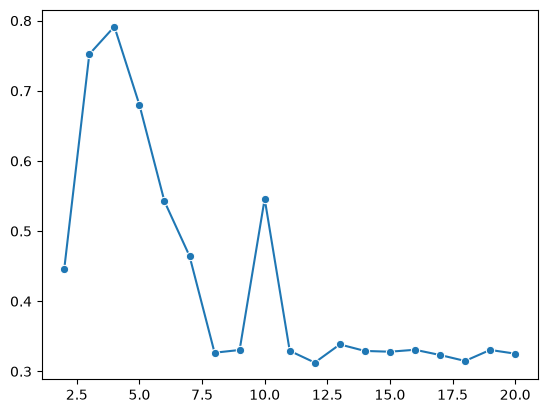

In [25]:
# plot - K & ss

sns.lineplot(x=range(2, 21), y=ss, marker='o')